In [7]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from tensorflow.keras.optimizers import SGD

np.random.seed(4)

In [2]:
def extract_features(file_path, max_pad_len=174):
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        # Extract 40 MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        # Pad or truncate the MFCCs to have a fixed length
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [3]:
# Read the CSV file
train_df = pd.read_csv('development.csv')

# Create the 'intention' column by combining 'action' and 'object'
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

# Update the 'path' column to include the full directory path
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']

features = []
labels = []

# Iterate over each row in the DataFrame
for index, row in train_df.iterrows():
    file_path = row['path']
    intent = row['intention']
    mfcc = extract_features(file_path)
    if mfcc is not None:
        features.append(mfcc)
        labels.append(intent)

features = np.array(features)
labels = np.array(labels)
print('Features shape:', features.shape)
print('Labels shape:', labels.shape)

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Features shape: (9854, 40, 174)
Labels shape: (9854,)


In [ ]:
# # Add channel dimension for CNN input
# features = features[..., np.newaxis]

# # Split the dataset (80% training, 20% testing)
# X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, shuffle=True, random_state=4)

# le = LabelEncoder()
# y_train_encoded = le.fit_transform(y_train)
# y_train = to_categorical(y_train_encoded)
# y_test_encoded = le.transform(y_test)
# y_test = to_categorical(y_test_encoded)

# print('X_train shape:', X_train.shape)
# print('y_train shape:', y_train.shape)
# print('X_test shape:', X_test.shape)
# print('y_test shape:', y_test.shape)


KeyboardInterrupt



In [4]:
# 1. Add channel dimension for CNN input
features = features[..., np.newaxis]  # shape: (num_samples, 40, 174, 1) for example

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, shuffle=True, random_state=4)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

# 4. Apply SMOTE to the training set
#    SMOTE expects a 2D array of shape (n_samples, n_features).
#    Since X_train is 4D for CNNs, we flatten it temporarily.
X_train_flat = X_train.reshape(X_train.shape[0], -1)

smote = SMOTE(random_state=4, sampling_strategy='not majority')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_flat, y_train_encoded)

# 5. Reshape the balanced training data back to 4D for the CNN
#    Update (40, 174) to match the MFCC shape you have.
X_train_balanced = X_train_balanced.reshape(X_train_balanced.shape[0], 40, 174, 1)

# 6. Convert the balanced labels to one-hot vectors
y_train_balanced = to_categorical(y_train_balanced)
y_test = to_categorical(y_test_encoded)

X_train = X_train_balanced
y_train = y_train_balanced

print('X_train_balanced shape:', X_train.shape)
print('y_train_balanced shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train_balanced shape: (14714, 40, 174, 1)
y_train_balanced shape: (14714, 7)
X_test shape: (1971, 40, 174, 1)
y_test shape: (1971, 7)


In [ ]:
# input_shape = X_train.shape[1:]

# model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.3))

# model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.3))

# model.add(Flatten())
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.3))
# model.add(Dense(y_train.shape[1], activation='softmax'))

# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.summary()

# history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,359 (10.58 MB)

 Trainable params: 2,772,359 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# input_shape = X_train.shape[1:]
# weight_decay = 1e-4
# dropout_rate = 0.4

# model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(dropout_rate))

# model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(dropout_rate))

# model.add(Flatten())
# model.add(Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)))
# model.add(Dropout(dropout_rate))
# model.add(Dense(y_train.shape[1], activation='softmax'))

# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.summary()

# # Early stopping callback
# # Stop if val_loss doesn't improve for 5 epochs
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,359 (10.58 MB)

 Trainable params: 2,772,359 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.1625 - loss: 3.6707 - val_accuracy: 0.1644 - val_loss: 1.9568
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.2293 - loss: 1.8824 - val_accuracy: 0.2998 - val_loss: 1.7210
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.3732 - loss: 1.6131 - val_accuracy: 0.4023 - val_loss: 1.5028
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.4330 - loss: 1.4557 - val_accuracy: 0.4394 - val_loss: 1.4482
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.4955 - loss: 1.3296 - val_accuracy: 0.4876 - val_loss: 1.3044
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.5314 - loss: 1.2338 - val_accuracy: 0.4845 - val_loss: 1.3170
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.5700 - loss: 1.1565 - val_accuracy: 0.5079 - val_loss: 1.2570
Epoch 8/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.5996 - loss: 1.1078 - 

In [ ]:
# # Example hyperparameters you can tune
# input_shape = X_train.shape[1:]
# weight_decay = 1e-4       # L2 regularization strength
# dropout_rate = 0.4        # Dropout fraction
# initial_lr = 1e-3         # Initial learning rate

# # Build a deeper CNN with BatchNorm and L2 regularization
# model = Sequential()

# # 1st Convolutional Block
# model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(dropout_rate))

# # 2nd Convolutional Block
# model.add(Conv2D( 64, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(dropout_rate))

# # 3rd Convolutional Block (optional, for deeper feature learning)
# model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(dropout_rate))

# # Flatten and Dense Layers
# model.add(Flatten())
# model.add(Dense( 256, activation='relu', kernel_regularizer=l2(weight_decay)))
# model.add(BatchNormalization())
# model.add(Dropout(dropout_rate))

# # Output Layer
# model.add(Dense(y_train_balanced.shape[1], activation='softmax'))

# # Compile with Adam optimizer (adjust learning rate as needed)
# optimizer = Adam(learning_rate=initial_lr)
# model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# model.summary()

# # Callbacks: ReduceLROnPlateau & EarlyStopping
# # reduce LR by half
# # wait 3 epochs with no improvement
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,062,727 (7.87 MB)

 Trainable params: 2,061,767 (7.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[reduce_lr, early_stopping])

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 106s 224ms/step - accuracy: 0.2859 - loss: 2.1760 - val_accuracy: 0.1497 - val_loss: 3.2753 - learning_rate: 0.0010
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.4968 - loss: 1.3907 - val_accuracy: 0.2740 - val_loss: 2.7503 - learning_rate: 0.0010
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.5792 - loss: 1.1669 - val_accuracy: 0.3572 - val_loss: 2.3515 - learning_rate: 0.0010
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 101s 219ms/step - accuracy: 0.6175 - loss: 1.0586 - val_accuracy: 0.3349 - val_loss: 2.6856 - learning_rate: 0.0010
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 108s 235ms/step - accuracy: 0.6523 - loss: 1.0060 - val_accuracy: 0.4333 - val_loss: 2.2603 - learning_rate: 0.0010
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 102s 222ms/step - accuracy: 0.6775 - loss: 0.9527 - val_accuracy: 0.5606 - val_loss: 1.2842 - learning_rate: 0.0010
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 100s 218ms/step - accuracy

In [10]:
# Example hyperparameters you can tune
input_shape = X_train.shape[1:]
weight_decay = 5e-4       # L2 regularization strength
dropout_rate = 0.4        # Dropout fraction
initial_lr = 1e-3         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Convolutional Block
model.add(Conv2D( 64, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Convolutional Block (optional, for deeper feature learning)
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense( 256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train_balanced.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,062,727 (7.87 MB)

 Trainable params: 2,061,767 (7.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test), callbacks=[reduce_lr, early_stopping])

Epoch 1/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 110s 117ms/step - accuracy: 0.2889 - loss: 2.3734 - val_accuracy: 0.2248 - val_loss: 2.7374 - learning_rate: 0.0010
Epoch 2/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 109s 119ms/step - accuracy: 0.5112 - loss: 1.6576 - val_accuracy: 0.2689 - val_loss: 3.3884 - learning_rate: 0.0010
Epoch 3/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 110s 119ms/step - accuracy: 0.5603 - loss: 1.5295 - val_accuracy: 0.4460 - val_loss: 1.9062 - learning_rate: 0.0010
Epoch 4/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 109s 119ms/step - accuracy: 0.5981 - loss: 1.4362 - val_accuracy: 0.4084 - val_loss: 2.2667 - learning_rate: 0.0010
Epoch 5/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 115s 125ms/step - accuracy: 0.6315 - loss: 1.4338 - val_accuracy: 0.4992 - val_loss: 1.8489 - learning_rate: 0.0010
Epoch 6/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 117s 127ms/step - accuracy: 0.6459 - loss: 1.4476 - val_accuracy: 0.5434 - val_loss: 1.6765 - learning_rate: 0.0010
Epoch 7/30
 99/920 ━━━━━━━━━━━━━━━━━━━━ 1:43 126ms/step - accura

Test loss: 0.9880572557449341
Test accuracy: 0.7153729200363159


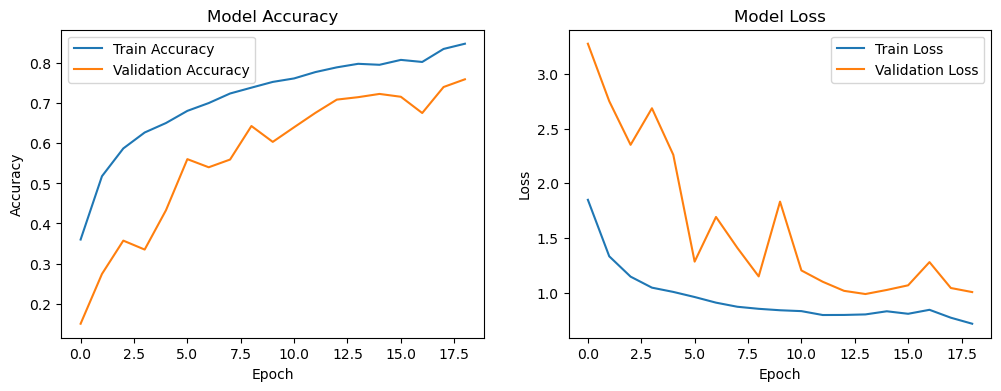

In [16]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Example hyperparameters you can tune
input_shape = X_train.shape[1:]
weight_decay = 1e-4       # L2 regularization strength
dropout_rate = 0.4        # Dropout fraction
initial_lr = 1e-3         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Convolutional Block
model.add(Conv2D( 64, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Convolutional Block (optional, for deeper feature learning)
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense( 256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train_balanced.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[reduce_lr, early_stopping])